# Insurance Prediction

In [16]:
import kagglehub
import os

path = kagglehub.dataset_download("rahulvyasm/medical-insurance-cost-prediction")

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        path = os.path.join(dirname, filename)
    
path

'/home/jm/.cache/kagglehub/datasets/rahulvyasm/medical-insurance-cost-prediction/versions/1/medical_insurance.csv'

In [17]:
import pandas as pd

# Read dataset
df = pd.read_csv('/home/jm/.cache/kagglehub/datasets/rahulvyasm/medical-insurance-cost-prediction/versions/1/medical_insurance.csv')

### Exploratory Data Analysis

In [18]:
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("First 5 rows:\n", df.head())
print("Missing values:\n", df.isnull().sum())
print("Data Types:\n", df.dtypes)

Dataset Shape: (2772, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
First 5 rows:
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Data Types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [19]:
# Map categorical columns to numeric values
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

In [20]:
# Drop non numeric columns for correlation analysis
df.drop(columns=['region'], inplace=True, axis=1)

df.describe()

,age,sex,bmi,children,smoker,charges
count,2772.000000,2772.000000,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,0.492785,30.701349,1.101732,0.203463,13261.369959
std,14.081459,0.500038,6.129449,1.214806,0.402647,12151.768945
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,26.000000,0.000000,26.220000,0.000000,0.000000,4687.797000
50%,39.000000,0.000000,30.447500,1.000000,0.000000,9333.014350
75%,51.000000,1.000000,34.770000,2.000000,0.000000,16577.779500
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

sns.set_style('whitegrid')

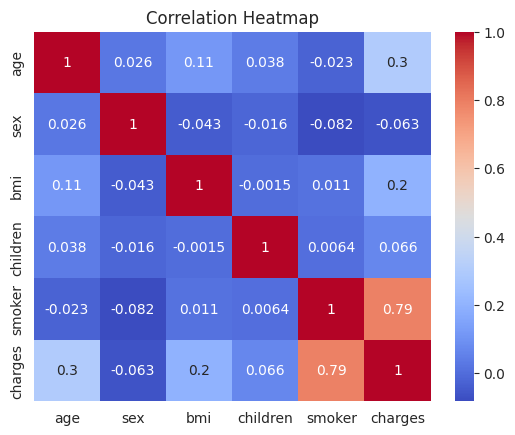

In [22]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [23]:
# Drop columns with low correlation to target variable 'charges'
df.drop(columns=['sex', 'children'], inplace=True, axis=1)

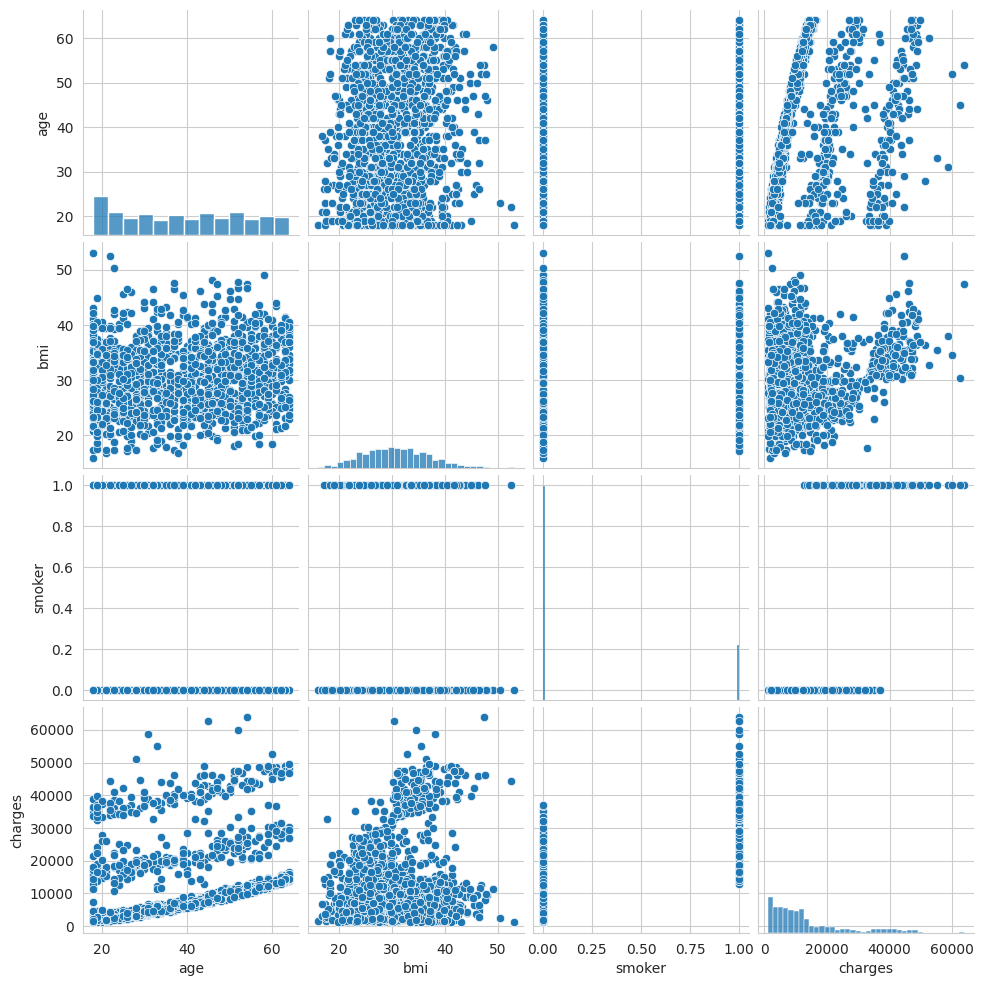

In [24]:
sns.pairplot(df)

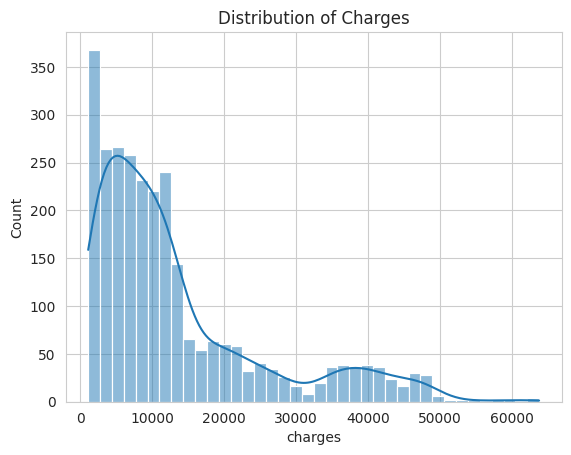

In [25]:
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges')
plt.show()

### Model Creation

In [27]:
# Split data into features and target variable
X = df.drop('charges', axis=1)
y = df['charges']

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# Create the model
model = LinearRegression()

In [29]:
from sklearn.preprocessing import MinMaxScaler
# Scale features
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
# Get model intercepts and coefficients
intercept = model.intercept_
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])

print("Model Intercept:", intercept)
print("Model Coefficients:\n", coefficients)
print(coefficients)

Model Intercept: -1480.3048517898005
Model Coefficients:
          Coefficient
age     11658.143283
bmi     11383.590495
smoker  23961.442291
         Coefficient
age     11658.143283
bmi     11383.590495
smoker  23961.442291


**Linear Regression Equation**

The linear regression model can be represented by the following equation:

$$\text{Scores} = \beta_0 + \beta_1 \times \text{Feature}_1 + \beta_2 \times \text{Feature}_2 + ... + \beta_n \times \text{Feature}_n$$

Where:
- $\beta_0$ is the intercept (${-1480.304}$ in our case)
- $\beta_1, \beta_2, ..., \beta_n$ are the coefficients for each feature
- $\text{Feature}_1, \text{Feature}_2, ..., \text{Feature}_n$ are the input features

Using our model's calculated values:

$$\text{charges} = \text{intercept} + \sum_{i=1}^{n} \text{coefficient}_i \times \text{Feature}_i$$

This equation allows us to insurance charges based on the features in our dataset.

In [33]:
# Make predictions on the training set
y_train_pred = model.predict(X_train)
# Make predictions on the test set
y_test_pred = model.predict(X_test)

In [34]:
# Create a DataFrame to compare actual vs predicted values
train_comparison = pd.DataFrame({'Actual': y_train, 'Predicted': y_train_pred})
print("Training Set Comparison:\n", train_comparison.head())

Training Set Comparison:
            Actual    Predicted
1      1725.55230  3974.140849
1309   6875.96100  9322.388249
1343   2395.17155  2201.724857
2396   8269.04400  8217.633229
853   11729.67950  9775.767321


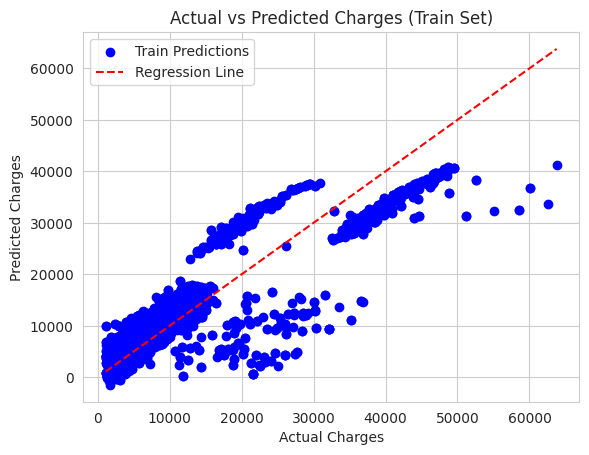

In [35]:
plt.scatter(y_train, y_train_pred, color='blue', label='Train Predictions')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--', label='Regression Line')

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges (Train Set)')
plt.legend()
plt.show()

In [36]:
from sklearn.metrics import r2_score

train_score = r2_score(y_train, y_train_pred)
print(f"Score on train set: {train_score*100:.2f}%")

Score on train set: 74.29%


In [37]:
validation_score = r2_score(y_test, y_test_pred)
print(f"Score on validation set: {validation_score*100:.2f}%")

Score on validation set: 76.38%


<Axes: xlabel='charges'>

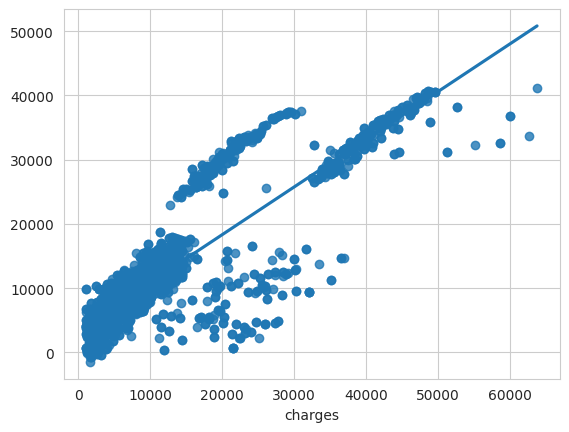

In [ ]:
sns.regplot(x=y_train, y=y_train_pred, ci=None, line_kws={"color":"r","alpha":0.7,"lw":2})